# import

In [2]:
import copy
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from shapely.affinity import affine_transform
from shapely.geometry import Point, LineString, Polygon, MultiPoint, MultiLineString, MultiPolygon, box
from geopandas import GeoSeries, GeoDataFrame
from shapely.ops import split, unary_union, polygonize
import pickle

# Config

# read data

In [3]:
gdf_kq = gpd.read_file('combined.geopandas',driver='GeoJSON')
gdf_kq.explore(tiles=None)

/home/lxh/anaconda3/envs/urban/lib/python3.11/site-packages/pyogrio/raw.py:198: RuntimeWarning: driver GeoJSON does not support open option DRIVER
  return ogr_read(


In [4]:
gdf_kq.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Id        70 non-null     int32   
 1   type      70 non-null     object  
 2   geometry  70 non-null     geometry
dtypes: geometry(1), int32(1), object(1)
memory usage: 1.5+ KB


# translate, rescale, obtain intersections

In [4]:
def translate_and_rescale(gdf_in,scaling_factor=10):
    gdf=gdf_in
    # Get the minimum x and y values from total_bounds
    x_min, y_min, x_max, y_max = gdf.total_bounds
    
    # Calculate the translation values
    x_translation = -x_min
    y_translation = -y_min
    
    # Apply the translation to the GeoDataFrame
    gdf['geometry'] = gdf.translate(xoff=x_translation, yoff=y_translation)
    
    #scaling_factor = 0.1  # Scale down by a factor of 10
    
    # Create the scaling matrix
    scaling_matrix = [scaling_factor, 0, 0, scaling_factor, 0, 0]
    
    # Apply the scaling transformation to the GeoDataFrame
    gdf['geometry'] = gdf['geometry'].apply(lambda geom: affine_transform(geom, scaling_matrix))

    return gdf

In [7]:
gdf_kq.crs=None
gdf_scaled= translate_and_rescale(gdf_kq)

In [13]:
gdf_scaled=translate_and_rescale(gdf_scaled,scaling_factor=0.0001)
gdf_scaled

,Id,type,geometry
0,0,main_road,"LINESTRING (0 2606.267, 86.458 2021.275, 140.0..."
1,0,main_road,"LINESTRING (1643.995 815.279, 1293.739 836.218..."
2,0,main_road,"LINESTRING (1642.092 950.433, 913.584 952.188)"
3,0,main_road,"LINESTRING (749.318 6.262, 1400.338 67.177, 17..."
4,0,main_road,"LINESTRING (216.522 1987.181, 189.193 2269.606..."
...,...,...,...
65,0,road,"LINESTRING (1140.66 441.398, 1467.78 428.43)"
66,0,road,"LINESTRING (1142.583 501.767, 1140.66 441.398)"
67,0,road,"LINESTRING (1142.583 501.767, 659.036 529.649,..."
68,0,road,"LINESTRING (655.595 656.887, 1252.569 581.188)"


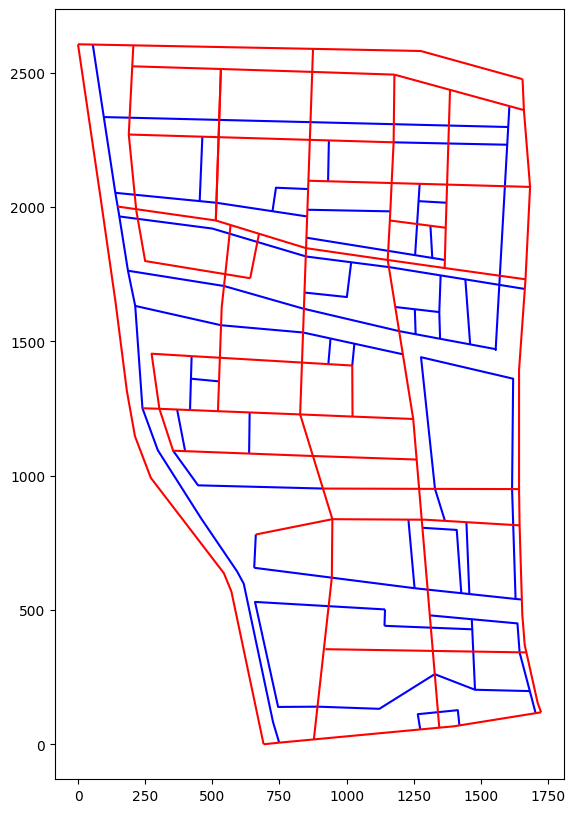

In [18]:
gdf_road = gdf_arranged[gdf_arranged['type'] == 'road']
gdf_main = gdf_arranged[gdf_arranged['type'] == 'main_road']
ax = gdf_road.plot(color='blue', markersize=5, figsize=(10, 10))
ax = gdf_main.plot(ax=ax, color='red', markersize=20)

# visualization

In [5]:
def plot_gdf(gdf, filename=None, **kwargs):
    fig, ax = plt.subplots(1, 1, figsize=(15,15))
    gdf.plot(ax=ax, linewidth=2, markersize=15, **kwargs)
    ax.tick_params(axis='both', which='major', labelsize=15)
    if filename is not None:
        plt.savefig(filename)
    plt.show()

# generate initial plan

## obtain simplified road segments

In [6]:
def format_roads_list(gdf):
    # 筛选LineString类型的几何对象
    linestrings = gdf[gdf.geometry.geom_type == 'LineString']
    
    # 开始构建输出字符串
    output = "roads = [\n"
    
    # 遍历每个LineString并格式化
    for i, (idx, row) in enumerate(linestrings.iterrows()):
        geom = row.geometry
        coords = list(geom.coords)
        
        # 构建坐标部分，确保坐标为整数
        coords_str = ", ".join([f"({x}, {y})" for x, y in coords])
        
        # 添加到输出字符串，使用索引作为道路标识
        output += f"    LineString([{coords_str}]), # Road_{i+1}"
        
        # 如果不是最后一行，添加逗号和换行符
        if i < len(linestrings) - 1:
            output += ",\n"
        else:
            output += "\n"
    
    output += "]"
    return output



In [ ]:
# 生成格式化的道路列表
formatted_roads = format_roads_list(gdf_arranged)
print(formatted_roads)

In [85]:
def aiaggregate(lines):
    # First, combine all lines using unary_union to handle overlaps
    combined_lines = unary_union(lines)
    
    # Extract individual segments
    if combined_lines.geom_type == 'LineString':
        all_segments = [combined_lines]
    else:  # MultiLineString
        all_segments = list(combined_lines.geoms)
    
    # Process multi-segment lines into individual segments
    roads = []
    for line in all_segments:
        if len(line.coords) > 2:
            # Split multi-segment roads into individual segments
            roads.extend([LineString([line.coords[i], line.coords[i+1]]) 
                         for i in range(len(line.coords) - 1)])
        else:
            roads.append(line)
    
    # Generate road types
    roads_type = [ROAD for _ in range(len(roads))]
    
    # Extract intersection points
    intersections = []
    for road in roads:
        intersections.append(Point(road.coords[0]))
        intersections.append(Point(road.coords[1]))
    
    # Get unique intersection points
    intersections = list(unary_union(intersections).geoms)
    intersections_type = [INTERSECTION for _ in range(len(intersections))]
    
    # Generate polygons from the roads
    feasibles = list(polygonize(roads))
    feasibles_type = [FEASIBLE for _ in range(len(feasibles))]
    
    # Combine all data
    types = feasibles_type + roads_type + intersections_type 
    geometries = feasibles + roads + intersections
    
    # Create GeoDataFrame
    gdf = GeoDataFrame({
        'id': list(range(len(types))),
        'type': types,
        'existence': [True for _ in range(len(types))],
        'geometry': geometries
    }).set_index('id')
    
    return gdf

In [ ]:
gdf_aggregated = aiaggregate(roads)
plot_gdf(gdf_aggregated[gdf_aggregated.geom_type=='Polygon'])
#gdf_aggregated[gdf_aggregated.geom_type!='Polygon'].explore()

In [73]:
gdf_aggregated.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 682 entries, 0 to 681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   id         682 non-null    int32   
 1   type       682 non-null    int32   
 2   existence  682 non-null    bool    
 3   geometry   682 non-null    geometry
dtypes: bool(1), geometry(1), int32(2)
memory usage: 11.5 KB


In [7]:
def round_all_to_int(geom):
    """将几何对象的坐标四舍五入为整数"""
    
    if geom is None:
        return None
    
    # 处理 Point
    if geom.geom_type == 'Point':
        return Point(round(geom.x), round(geom.y))
    
    # 处理 LineString
    elif geom.geom_type == 'LineString':
        rounded_coords = [(round(x), round(y)) for x, y in geom.coords]
        return LineString(rounded_coords)
    
    # 处理 Polygon
    elif geom.geom_type == 'Polygon':
        exterior_rounded = [(round(x), round(y)) for x, y in geom.exterior.coords]
        interiors_rounded = [[(round(x), round(y)) for x, y in interior.coords] for interior in geom.interiors]
        return Polygon(exterior_rounded, interiors_rounded)
    
    # 处理 MultiPoint
    elif geom.geom_type == 'MultiPoint':
        rounded_points = [Point(round(p.x), round(p.y)) for p in geom.geoms]
        return MultiPoint(rounded_points)
    
    # 处理 MultiLineString
    elif geom.geom_type == 'MultiLineString':
        rounded_lines = [LineString([(round(x), round(y)) for x, y in line.coords]) for line in geom.geoms]
        return MultiLineString(rounded_lines)
    
    # 处理 MultiPolygon
    elif geom.geom_type == 'MultiPolygon':
        rounded_polygons = []
        for polygon in geom.geoms:
            exterior_rounded = [(round(x), round(y)) for x, y in polygon.exterior.coords]
            interiors_rounded = [[(round(x), round(y)) for x, y in interior.coords] for interior in polygon.interiors]
            rounded_polygons.append(Polygon(exterior_rounded, interiors_rounded))
        return MultiPolygon(rounded_polygons)
    
    # 如果是其他类型，则返回原始几何对象
    else:
        return geom

In [45]:
gdf_aggregated_round=gdf_aggregated
gdf_aggregated_round['geometry'] = gdf_aggregated_round['geometry'].apply(round_all_to_int)

In [46]:
gdf_aggregated_round.to_file('kq_aggregated_round.geojson', driver='GeoJSON')

/home/lxh/anaconda3/envs/urban/lib/python3.11/site-packages/pyogrio/geopandas.py:662: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


In [130]:
gdf_aggregated=gpd.read_file('kq_aggre_update.geojson', driver='GeoJSON')

gdf_aggregated.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 637 entries, 0 to 636
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   id         637 non-null    int32   
 1   type       637 non-null    int32   
 2   existence  637 non-null    bool    
 3   geometry   637 non-null    geometry
dtypes: bool(1), geometry(1), int32(2)
memory usage: 10.7 KB


/home/lxh/anaconda3/envs/urban/lib/python3.11/site-packages/pyogrio/raw.py:198: RuntimeWarning: driver GeoJSON does not support open option DRIVER
  return ogr_read(


In [8]:
def scale_gdf(gdf_in, scaling_factor=0.01):

    gdf=gdf_in.copy()
    # Create the scaling matrix
    scaling_matrix = [scaling_factor, 0, 0, scaling_factor, 0, 0]
    
    # Apply the scaling transformation to the GeoDataFrame
    gdf['geometry'] = gdf['geometry'].apply(lambda geom: affine_transform(geom, scaling_matrix))

    return gdf

In [132]:
gdf_aggregated.head()

,id,type,existence,geometry
0,0,2,True,"LINESTRING (0 2606, 86 2021)"
1,1,2,True,"LINESTRING (86 2021, 140 1644)"
2,2,2,True,"LINESTRING (140 1644, 182 1315)"
3,3,2,True,"LINESTRING (182 1315, 212 1147)"
4,4,2,True,"LINESTRING (212 1147, 271 992)"


In [133]:
gdf_aggregated100=scale_gdf(gdf_aggregated,scaling_factor=0.01)
gdf_aggregated100[gdf_aggregated100.geom_type!='Polygon'].explore(tiles=None)

In [134]:
roads = gdf_aggregated[gdf_aggregated.geometry.geom_type == 'LineString'].geometry.tolist()
print(roads)

[<LINESTRING (0 2606, 86 2021)>, <LINESTRING (86 2021, 140 1644)>, <LINESTRING (140 1644, 182 1315)>, <LINESTRING (182 1315, 212 1147)>, <LINESTRING (212 1147, 271 992)>, <LINESTRING (271 992, 422 795)>, <LINESTRING (422 795, 543 637)>, <LINESTRING (543 637, 571 569)>, <LINESTRING (571 569, 691 0)>, <LINESTRING (1644 815, 1620 816)>, <LINESTRING (1620 816, 1446 827)>, <LINESTRING (1446 827, 1366 832, 1294 836)>, <LINESTRING (1294 836, 1280 836)>, <LINESTRING (1280 836, 1230 836)>, <LINESTRING (1230 836, 947 838)>, <LINESTRING (947 838, 662 781)>, <LINESTRING (1642 950, 1616 950)>, <LINESTRING (1616 950, 1329 951)>, <LINESTRING (1329 951, 1270 951)>, <LINESTRING (1270 951, 914 952)>, <LINESTRING (749 6, 878 18)>, <LINESTRING (878 18, 1274 55)>, <LINESTRING (1274 55, 1345 62)>, <LINESTRING (1345 62, 1400 67)>, <LINESTRING (1400 67, 1420 70)>, <LINESTRING (1420 70, 1704 116)>, <LINESTRING (1704 116, 1724 119)>, <LINESTRING (217 1987, 216 1992)>, <LINESTRING (216 1992, 211 2046)>, <LINESTR

In [135]:
from shapely.geometry import LineString

target_line = LineString([(1141.0, 441.0), (1121.0, 351.0)])
if target_line in roads:
    print("The target LineString exists in the roads list.")
else:
    print("The target LineString does not exist in the roads list.")

The target LineString exists in the roads list.


In [94]:
roads.append(LineString([(1141.0, 441.0 ),(1121.0, 351.0)]))
roads

[<LINESTRING (0 2606, 86 2021)>,
 <LINESTRING (86 2021, 140 1644)>,
 <LINESTRING (140 1644, 182 1315)>,
 <LINESTRING (182 1315, 212 1147)>,
 <LINESTRING (212 1147, 271 992)>,
 <LINESTRING (271 992, 422 795)>,
 <LINESTRING (422 795, 543 637)>,
 <LINESTRING (543 637, 571 569)>,
 <LINESTRING (571 569, 691 0)>,
 <LINESTRING (1644 815, 1620 816)>,
 <LINESTRING (1620 816, 1446 827)>,
 <LINESTRING (1446 827, 1294 836)>,
 <LINESTRING (1294 836, 1280 836)>,
 <LINESTRING (1280 836, 1230 836)>,
 <LINESTRING (1230 836, 947 838)>,
 <LINESTRING (947 838, 662 781)>,
 <LINESTRING (1642 950, 1616 950)>,
 <LINESTRING (1616 950, 1329 951)>,
 <LINESTRING (1329 951, 1270 951)>,
 <LINESTRING (1270 951, 914 952)>,
 <LINESTRING (749 6, 878 18)>,
 <LINESTRING (878 18, 1274 55)>,
 <LINESTRING (1274 55, 1345 62)>,
 <LINESTRING (1345 62, 1400 67)>,
 <LINESTRING (1400 67, 1420 70)>,
 <LINESTRING (1420 70, 1704 116)>,
 <LINESTRING (1704 116, 1724 119)>,
 <LINESTRING (217 1987, 216 1992)>,
 <LINESTRING (216 1992, 21

In [ ]:
formatted_roads = format_roads_list(gdf_aggregated[gdf_aggregated.geometry.geom_type == 'LineString'])
print(formatted_roads)

In [136]:
gdf1=aiaggregate(roads)

In [140]:
gdf_aggregated100=scale_gdf(gdf1,scaling_factor=0.01)
gdf_aggregated100[gdf_aggregated100.geom_type!='Polygon'].explore(tiles=None)

In [138]:
gdf1.head()

,type,existence,geometry
id,,,
0,1,True,"POLYGON ((86 2021, 0 2606, 55 2605, 96 2335, 1..."
1,1,True,"POLYGON ((1644 815, 1620 816, 1616 950, 1642 9..."
2,1,True,"POLYGON ((1620 816, 1644 815, 1654 484, 1663 3..."
3,1,True,"POLYGON ((1620 816, 1446 827, 1366 832, 1329 9..."
4,1,True,"POLYGON ((1446 827, 1620 816, 1629 541, 1457 5..."


In [ ]:
polygon_ids = gdf_aggregated[gdf_aggregated.geometry.geom_type == 'Polygon']['id']


In [98]:
polygon_ids


544    544
545    545
546    546
547    547
548    548
      ... 
632    632
633    633
634    634
635    635
636    636
Name: id, Length: 93, dtype: int32

In [142]:
gdf1.to_file('gdf1.geojson',driver='GeoJSON')

/home/lxh/anaconda3/envs/urban/lib/python3.11/site-packages/pyogrio/geopandas.py:662: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


In [12]:
gdf1=gpd.read_file('gdf1.geojson',driver='GeoJSON')

/home/lxh/anaconda3/envs/urban/lib/python3.11/site-packages/pyogrio/raw.py:198: RuntimeWarning: driver GeoJSON does not support open option DRIVER
  return ogr_read(


In [ ]:
gdf1_poly= gdf1[gdf1.geometry.geom_type == 'Polygon']
gdf1_poly.geometry.tolist()

In [112]:
gdf1_poly.head()

,type,existence,geometry
id,,,
0,1,True,"POLYGON ((86 2021, 0 2606, 55 2605, 96 2335, 1..."
1,1,True,"POLYGON ((1644 815, 1620 816, 1616 950, 1642 9..."
2,1,True,"POLYGON ((1620 816, 1644 815, 1654 484, 1663 3..."
3,1,True,"POLYGON ((1620 816, 1446 827, 1294 836, 1280 8..."
4,1,True,"POLYGON ((1446 827, 1620 816, 1629 541, 1457 5..."


In [113]:
id_min, id_max = gdf1.index.min(), gdf1.index.max()
print(f"gdf1 id 范围: {id_min} - {id_max}")

gdf1 id 范围: 0 - 652


In [139]:
gdf_simplified=gdf1
print(len(gdf_simplified[gdf_simplified.geom_type=='LineString']))
print(len(gdf_simplified[gdf_simplified.geom_type=='Point']))
print(len(gdf_simplified[gdf_simplified.geom_type=='Polygon']))

328
226
103


In [126]:
polygon_ids1 = gdf1[gdf1.geometry.geom_type == 'Polygon']['id']


In [127]:
polygon_ids1


0        0
1        1
2        2
3        3
4        4
      ... 
96      96
97      97
98      98
99      99
100    100
Name: id, Length: 101, dtype: int32

In [ ]:
# 筛选出所有 Polygon 的行

# 获取 id 的最小值和最大值
id_min, id_max = polygon_ids.min(), polygon_ids.max()

print(f"Polygon id 范围: {id_min} - {id_max}")

In [ ]:
gdf_aggregated_update=aiaggregate(roads)
gdf_aggregated_update.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 637 entries, 0 to 636
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   type       637 non-null    int64   
 1   existence  637 non-null    bool    
 2   geometry   637 non-null    geometry
dtypes: bool(1), geometry(1), int64(1)
memory usage: 15.6 KB


In [10]:
gdf_aggregated_update=gpd.read_file('kq_aggre_update.geojson', driver='GeoJSON')
gdf_aggregated_update.head()

/home/lxh/anaconda3/envs/urban/lib/python3.11/site-packages/pyogrio/raw.py:198: RuntimeWarning: driver GeoJSON does not support open option DRIVER
  return ogr_read(


,id,type,existence,geometry
0,0,2,True,"LINESTRING (0 2606, 86 2021)"
1,1,2,True,"LINESTRING (86 2021, 140 1644)"
2,2,2,True,"LINESTRING (140 1644, 182 1315)"
3,3,2,True,"LINESTRING (182 1315, 212 1147)"
4,4,2,True,"LINESTRING (212 1147, 271 992)"


In [48]:
gdf_aggregated100=scale_gdf(gdf_aggregated_update,scaling_factor=0.01)
gdf_aggregated100[gdf_aggregated100.geom_type!='Polygon'].explore(tiles=None)

In [49]:
gdf_simplified=gdf_aggregated
print(len(gdf_simplified[gdf_simplified.geom_type=='LineString']))
print(len(gdf_simplified[gdf_simplified.geom_type=='Point']))
print(len(gdf_simplified[gdf_simplified.geom_type=='Polygon']))

340
262
80


In [50]:
gdf_simplified=gdf_aggregated_update
print(len(gdf_simplified[gdf_simplified.geom_type=='LineString']))
print(len(gdf_simplified[gdf_simplified.geom_type=='Point']))
print(len(gdf_simplified[gdf_simplified.geom_type=='Polygon']))

318
226
93


In [9]:
def plot_polygons_with_ids(gdf_polygon, figsize=(8, 6), dpi=100):
    """
    在指定大小的画布上绘制所有Polygon并显示其ID
    
    参数:
    gdf_polygon : GeoDataFrame
        包含Polygon几何对象的GeoDataFrame
    figsize : tuple, 可选
        画布大小，默认为(8, 6)英寸，乘以dpi得到像素大小
    dpi : int, 可选
        分辨率，默认为100
    """
    # 创建图形和坐标轴
    #fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    # 绘制Polygons
    gdf_polygon.plot(ax=ax, alpha=0.5, edgecolor='black', facecolor='lightgray',aspect=1)
    
    # 为每个Polygon添加ID标签
    for idx, row in gdf_polygon.iterrows():
        # 获取Polygon的中心点坐标
        centroid = row.geometry.centroid
        # 添加文本标签
        ax.text(centroid.x, centroid.y, str(idx), 
                fontsize=8, ha='center', va='center',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
    
    # 设置图形边界
    minx, miny, maxx, maxy = gdf_polygon.total_bounds
    w, h = maxx - minx, maxy - miny
    ax.set_xlim(minx -0.05 * w  , maxx +0.05 * w)
    #ax.set_ylim(miny - 0.05 * h, maxy + 0.05 * h)
    
    # 移除坐标轴刻度
    ax.set_xticks([])
    ax.set_yticks([])
    
    # 添加标题
    ax.set_title('Polygons with IDs')
    
    # 确保边框可见
    for spine in ax.spines.values():
        spine.set_visible(True)
    
    plt.tight_layout()
    plt.show()
    
    return fig, ax

In [45]:
import numpy as np
def plot_polygons_with_ids(gdf_polygon, figsize=(10, 10), dpi=100):
    """
    在指定大小的画布上绘制所有Polygon并显示其ID
    
    参数:
    gdf_polygon : GeoDataFrame
        包含Polygon几何对象的GeoDataFrame
    figsize : tuple, 可选
        画布大小，默认为(10, 10)英寸，乘以dpi得到像素大小
    dpi : int, 可选
        分辨率，默认为100
    """
    # 创建图形和坐标轴
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    
    # 检查GeoDataFrame是否为空
    if gdf_polygon.empty:
        ax.text(0.5, 0.5, "No polygons to display", 
                ha='center', va='center', transform=ax.transAxes)
        plt.show()
        return fig, ax
    
    # 手动绘制每个多边形，而不是使用GeoPandas的plot方法
    for idx, row in gdf_polygon.iterrows():
        try:
            # 提取多边形的外部坐标
            xs, ys = row.geometry.exterior.xy
            # 使用Matplotlib的fill函数绘制多边形
            ax.fill(xs, ys, alpha=0.5, edgecolor='black', facecolor='lightgray')
            
            # 获取Polygon的中心点坐标
            centroid = row.geometry.centroid
            # 添加文本标签
            ax.text(centroid.x, centroid.y, str(idx), 
                    fontsize=8, ha='center', va='center',
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
        except Exception as e:
            print(f"Failed to plot polygon with ID {idx}: {e}")
    
    # 设置图形边界
    try:
        bounds = gdf_polygon.total_bounds
        if np.all(np.isfinite(bounds)):
            minx, miny, maxx, maxy = bounds
            w, h = maxx - minx, maxy - miny
            ax.set_xlim(minx - 0.05 * w, maxx + 0.05 * w)
            ax.set_ylim(miny - 0.05 * h, maxy + 0.05 * h)
    except:
        # 如果无法设置边界，尝试自动缩放
        ax.autoscale()
    
    # 移除坐标轴刻度
    ax.set_xticks([])
    ax.set_yticks([])
    
    # 添加标题
    ax.set_title('Polygons with IDs')
    
    # 确保边框可见
    for spine in ax.spines.values():
        spine.set_visible(True)
    
    plt.tight_layout()
    plt.show()
    
    return fig, ax

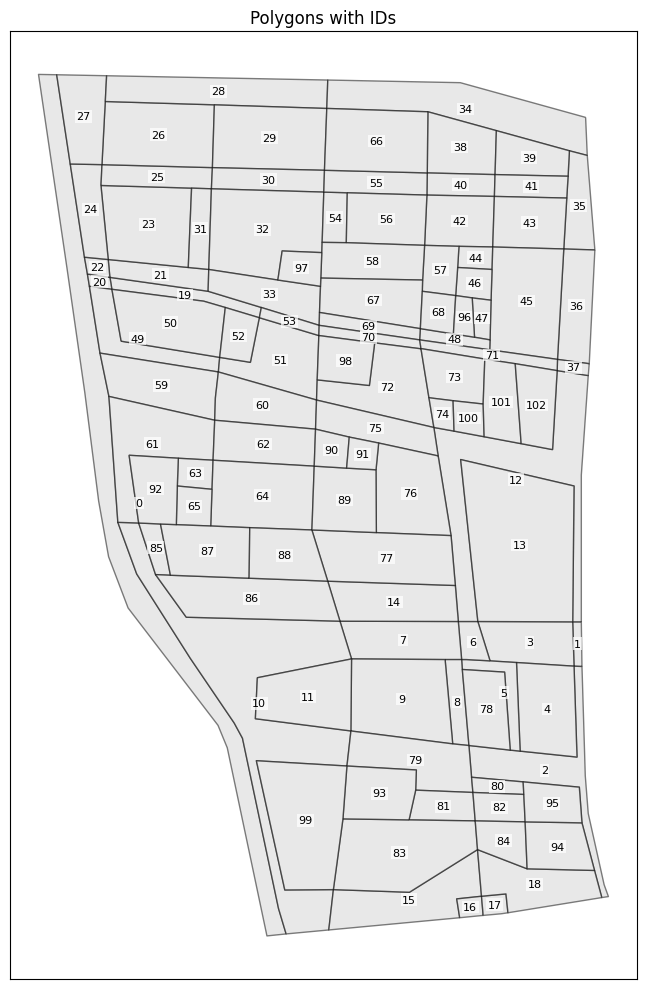

(<Figure size 1000x1000 with 1 Axes>,
 <Axes: title={'center': 'Polygons with IDs'}>)

In [14]:
gdf_simplified=gdf1
gdf_polygon = gdf_simplified[gdf_simplified.geom_type=='Polygon']
plot_polygons_with_ids(gdf_polygon, figsize=(10, 10), dpi=100)

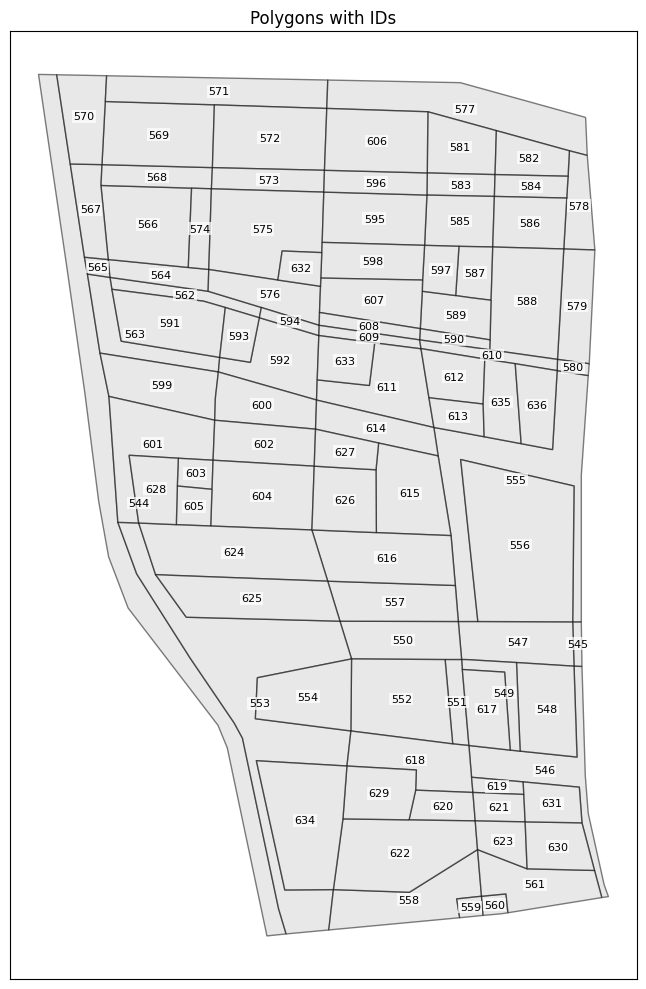

(<Figure size 1000x1000 with 1 Axes>,
 <Axes: title={'center': 'Polygons with IDs'}>)

In [12]:
gdf_simplified=gdf_aggregated_update
gdf_polygon = gdf_simplified[gdf_simplified.geom_type=='Polygon']
plot_polygons_with_ids(gdf_polygon, figsize=(10, 10), dpi=100)

## initial land use conditions

In [96]:
NON_BLOCK_LAND_USE = (
    'outside',
    'feasible',
    'road',
    'boundary'
)

BLOCK_LAND_USE = (
    'residential',
    'business',
    'business_h',
    'green_l',
    'residential_h',
    'school',
    'hospital_l',
    'hospital_s',
    'recreation',
    'river',
    'expressway',
    'a2',
    'a3',
    'a5',
    'rb',
    's1',
    'industry' 
)

LAND_USE = (
    NON_BLOCK_LAND_USE + BLOCK_LAND_USE)

OUTSIDE = 0
FEASIBLE = 1
ROAD = 2
BOUNDARY = 3
RESIDENTIAL = 4
BUSINESS = 5
BUSINESS_H = 6
GREEN_L = 7
RESIDENTIAL_H = 8
SCHOOL = 9
HOSPITAL_L = 10
HOSPITAL_S = 11
RECREATION = 12
RIVER = 13
EXPRESSWAY = 14
A2 = 15
A3 = 16
A5 = 17
RB = 18
S1 = 19
INDUSTRY = 20


LAND_USE_ID = (
    OUTSIDE,
    FEASIBLE,
    ROAD,
    BOUNDARY,
    RESIDENTIAL,
    BUSINESS,
    BUSINESS_H,
    GREEN_L,
    RESIDENTIAL_H,
    SCHOOL,
    HOSPITAL_L,
    HOSPITAL_S,
    RECREATION,
    RIVER,
    EXPRESSWAY,
    A2,
    A3,
    A5,
    RB,
    S1,
    INDUSTRY,
)

BLOCK_LAND_TYPE = (
    RESIDENTIAL,
    BUSINESS,
    BUSINESS_H,
    GREEN_L,
    RESIDENTIAL_H,
    SCHOOL,
    HOSPITAL_L,
    HOSPITAL_S,
    RECREATION,
    RIVER,
    EXPRESSWAY,
    A2,
    A3,
    A5,
    RB,
    S1,
    INDUSTRY,
)

NUM_TYPES = len(LAND_USE_ID)

LAND_USE_ID_MAP = dict(
    zip(LAND_USE, LAND_USE_ID))

LAND_USE_ID_MAP_INV = dict(
    zip(LAND_USE_ID, LAND_USE))

INTERSECTION = 21

RESIDENTIAL_ID = (
    RESIDENTIAL,
    RESIDENTIAL_H,
    RB
)

PUBLIC_SERVICES_ID = (
    BUSINESS,
    BUSINESS_H,
    SCHOOL,
    HOSPITAL_L, 
    HOSPITAL_S,
    RECREATION,
    A2,
    A3,
    A5,
    S1
)

PUBLIC_SERVICES = (
    'shopping',
    'working',
    'education',
    'medical care',
    'hospital_s',
    'entertainment',
)

GREEN_ID = (
    GREEN_L,
    RECREATION
)
GREEN_AREA_THRESHOLD = 5000

TYPE_COLOR_MAP = {
    'boundary': 'lightgreen',
    'business': '#e6005c',   # pink
    'feasible': 'white',
    'green_l': '#00ff00',
    'hospital_l': '#ff7f7e',    # light red
    'hospital_s': '#FF7F00',
    'business_h': '#ff0000',    # red
    'outside': 'black',
    'residential': '#ffff2d',  # yellow
    'residential_h': '#8B4513',   # brown
    'road': '#bbbbbb',      # grey
    'school': '#ff85c9',   # light pink
    'recreation': '#acffcf',   # light blue
    'river': '#4682B4',   # blue
    'expressway': 'gray',   # dark blue
    'a2': '#FF7F00',   # light orange
    'a3': '#FF85C9',   # light blue
    'a5': '#BB7F7E',   # light red
    's1': '#303030',   # light grey
    'rb': '#FFA500',   # orange red
    'industry': '#8B4513',   # brown
}

In [38]:
gdf_simplified.loc[gdf_simplified['type'] == 20, 'type'] = 21

In [40]:
gdf_simplified[gdf_simplified['type'] == 21].info()


<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 226 entries, 431 to 656
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   id         226 non-null    int32   
 1   type       226 non-null    int32   
 2   existence  226 non-null    bool    
 3   geometry   226 non-null    geometry
dtypes: bool(1), geometry(1), int32(2)
memory usage: 5.5 KB


In [94]:
# input land use for updated diagram
residential_ids = [26,29,66,38,39,23,32,42,43,58,9,83]
business_ids = [97,46,57,45,52,92,88,94]
a2_ids = [11,65,85,87,86,99,84,47]
a3_ids = [63,90,100,78,4,82]
a5_ids = [68]
rb_ids = [7,14]
recreation_ids = [16,17,96]
s1_ids = [44,47]
industry =[13]
green_l_ids = [1,2,10,15,18,79,5,8,6,12,74,21,22,33,69,48,36,24,31,25,27,30,54,55,40,41,35,28,34,49,59,60,61,75]
river_ids = [0]
expressway_ids = [20,19,53,70,71,37]
gdf_simplified.loc[residential_ids, 'type'] = RESIDENTIAL
gdf_simplified.loc[business_ids, 'type'] = BUSINESS
gdf_simplified.loc[green_l_ids, 'type'] = GREEN_L
gdf_simplified.loc[a2_ids, 'type'] = A2
gdf_simplified.loc[a3_ids, 'type'] = A3
gdf_simplified.loc[rb_ids, 'type'] = RB
gdf_simplified.loc[a5_ids, 'type'] = A5
gdf_simplified.loc[industry, 'type'] = INDUSTRY
gdf_simplified.loc[river_ids, 'type'] = RIVER
gdf_simplified.loc[expressway_ids, 'type'] = EXPRESSWAY
gdf_simplified.loc[s1_ids, 'type'] = S1
gdf_simplified.loc[recreation_ids, 'type'] = RECREATION

In [ ]:
# input land use
""" residential_ids = [569,572,606,581,582,566,575,598,611,557,552,585,586]
residential_h_ids = [556]
business_ids = [587,588,630,628,591,554]
school_ids = [595,625,617]
business_h_ids = [632,597,603]
green_l_ids = [544,570,571,577,567,568,573,596,583,584,578,579,574,565,563,599,600,601,614,555,553,551,549,546,545,558,561]
recreation_ids = [559,560,594,609,610,580,608,590,605]
hospital_l_ids = [589,624,548]
a2_ids = [621,623,608,590]
river_ids = [544]
expressway_ids = [562,594,609,610,580]
gdf_simplified.loc[residential_ids, 'type'] = RESIDENTIAL
gdf_simplified.loc[business_ids, 'type'] = BUSINESS
gdf_simplified.loc[school_ids, 'type'] = SCHOOL
gdf_simplified.loc[business_h_ids, 'type'] = BUSINESS_H
gdf_simplified.loc[green_l_ids, 'type'] = GREEN_L
gdf_simplified.loc[residential_h_ids, 'type'] = RESIDENTIAL_H
gdf_simplified.loc[recreation_ids, 'type'] = RECREATION
gdf_simplified.loc[hospital_l_ids, 'type'] = HOSPITAL_L
gdf_simplified.loc[a2_ids, 'type'] = HOSPITAL_S
gdf_simplified.loc[river_ids, 'type'] = RIVER
gdf_simplified.loc[expressway_ids, 'type'] = EXPRESSWAY """

In [77]:
print(gdf_simplified.area.sum())
print(gdf_simplified.unary_union.bounds)

3500700.0
(0.0, 0.0, 1724.0, 2606.0)


/tmp/ipykernel_4399/3772695229.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  print(gdf_simplified.area.sum())
/tmp/ipykernel_4399/3772695229.py:2: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  print(gdf_simplified.unary_union.bounds)


In [78]:
# 筛选多边形几何体
polygons_df = gdf_simplified[gdf_simplified.geometry.geom_type == 'Polygon'].copy()

# 计算每个多边形的面积并添加到数据框中
polygons_df['area'] = polygons_df.geometry.area

# 使用LAND_USE_ID_MAP_INV添加可读性更好的类型名称
polygons_df['land_use_name'] = polygons_df['type'].apply(lambda x: LAND_USE_ID_MAP_INV.get(x, 'unknown'))

# 按地块类型分组并计算统计数据
area_stats = polygons_df.groupby('land_use_name')['area'].agg([
    ('count', 'count'),  # 数量
    ('total_area', 'sum'),  # 总面积
    ('mean_area', 'mean'),  # 平均面积
    ('min_area', 'min'),  # 最小面积
    ('max_area', 'max'),  # 最大面积
    ('median_area', 'median'),  # 中位数面积
    ('std_area', 'std')  # 标准差
]).sort_values('total_area', ascending=False)

# 显示结果
print(area_stats)

               count    total_area      mean_area  min_area  max_area  \
land_use_name                                                           
green_l           34  1.140702e+06   33550.052744    3361.0  181264.0   
feasible          20  6.789987e+05   33949.935335    6480.0   61251.5   
residential       12  6.243095e+05   52025.791667   23337.0   78147.5   
a2                 7  2.674382e+05   38205.457225    8529.0   81383.5   
business           8  2.047770e+05   25597.125000    9459.0   67999.0   
river              1  1.565710e+05  156571.000000  156571.0  156571.0   
industry           1  1.409355e+05  140935.500000  140935.5  140935.5   
a3                 6  1.170468e+05   19507.799905    8650.0   46824.5   
rb                 2  8.219500e+04   41097.500000   39577.0   42618.0   
expressway         6  4.781100e+04    7968.500000    2428.0   15079.5   
recreation         3  1.530500e+04    5101.666667    4250.0    6697.5   
s1                 2  1.300900e+04    6504.500000  

/tmp/ipykernel_4399/106791077.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  polygons_df['area'] = polygons_df.geometry.area


## visualize

In [84]:
gdf_viz = copy.deepcopy(gdf_simplified[(gdf_simplified['existence'] == True) &
                                          (gdf_simplified['type'] != OUTSIDE) &
                                          (gdf_simplified['type'] != BOUNDARY) &
                                          (gdf_simplified['type'] != INTERSECTION)])
gdf_viz['legend'] = gdf_viz['type'].apply(lambda x: LAND_USE_ID_MAP_INV[x])
gdf_viz['legend']

0         river
1       green_l
2       green_l
3      feasible
4            a3
         ...   
426        road
427        road
428        road
429        road
430        road
Name: legend, Length: 431, dtype: object

In [85]:
gdf_viz['legend'].unique()

array(['river', 'green_l', 'feasible', 'a3', 'rb', 'residential', 'a2',
       'industry', 'recreation', 'expressway', 's1', 'business', 'a5',
       'road'], dtype=object)

In [81]:
existing_types = sorted([LAND_USE_ID_MAP_INV[var] for var in gdf_viz['type'].unique()])
cmap = ListedColormap(
    [TYPE_COLOR_MAP[var] for var in existing_types])

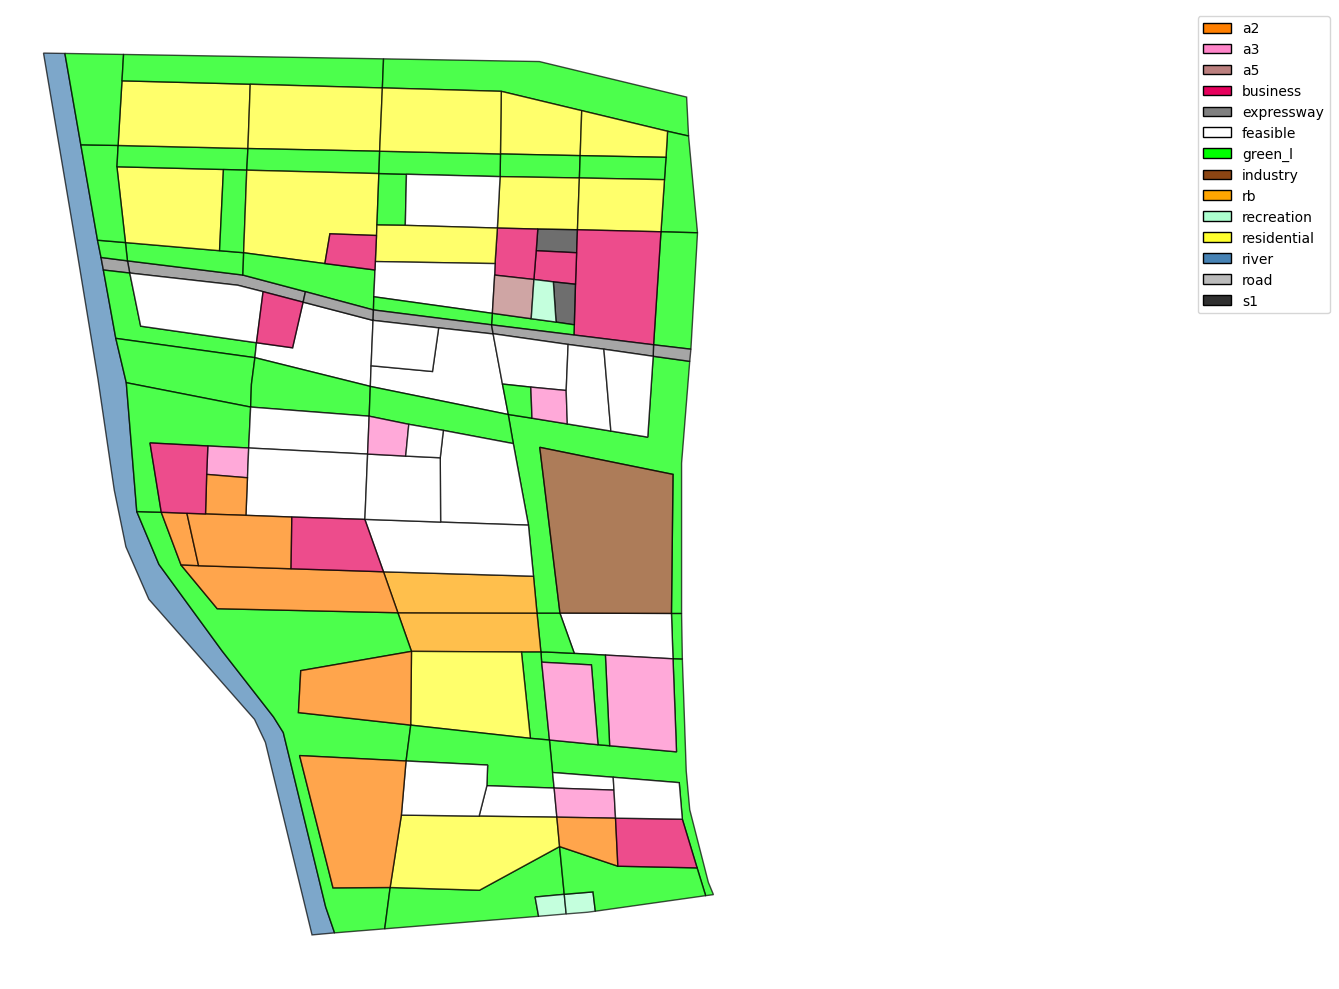

In [97]:
fig, ax = plt.subplots(figsize=(20, 10))

# 筛选多边形数据以提高绘图效率
gdf_viz_polygons = gdf_viz[gdf_viz.geometry.geom_type == 'Polygon']

# 手动绘制每个多边形
for idx, row in gdf_viz_polygons.iterrows():
    try:
        # 获取土地利用类型和相应的颜色
        land_use_type = row['legend']
        color = TYPE_COLOR_MAP.get(land_use_type, 'blue')  # 找不到颜色时默认为灰色
        
        # 提取多边形的外部坐标
        xs, ys = row.geometry.exterior.xy
        
        # 使用Matplotlib的fill函数绘制多边形
        ax.fill(xs, ys, color=color, alpha=0.7, edgecolor='black')
    except Exception as e:
        print(f"绘制ID为{idx}的多边形时出错: {e}")

# 手动创建图例
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=TYPE_COLOR_MAP[t], edgecolor='black', label=t) 
                  for t in existing_types]
ax.legend(handles=legend_elements, bbox_to_anchor=(1.8, 1))

# 移除坐标轴刻度和标签
plt.xticks([])
plt.yticks([])
plt.axis('off')

# 自动调整布局并显示
plt.tight_layout()
plt.show()

In [ ]:


gdf_viz = copy.deepcopy(gdf_simplified[(gdf_simplified['existence'] == True) &
                                          (gdf_simplified['type'] != OUTSIDE) &
                                          (gdf_simplified['type'] != BOUNDARY) &
                                          (gdf_simplified['type'] != INTERSECTION)])
gdf_viz['legend'] = gdf_viz['type'].apply(lambda x: LAND_USE_ID_MAP_INV[x])
#gdf_viz = gdf_viz[gdf_viz.geom_type=='Polygon']
existing_types = sorted([LAND_USE_ID_MAP_INV[var] for var in gdf_viz['type'].unique()])
cmap = ListedColormap(
    [TYPE_COLOR_MAP[var] for var in existing_types])
gdf_viz.plot(
    'legend',
    cmap=cmap,
    categorical=True,
    legend=True,
    legend_kwds={'bbox_to_anchor': (1.8, 1)}
)
plt.xticks([])
plt.yticks([])
plt.axis('off')
plt.show()

In [95]:
gdf_simplified.to_file('init_plan_kq.geojson', driver='GeoJSON')

In [59]:
d = dict()
d['gdf'] = gdf_simplified
with open('./init_plan_kq.pickle', 'wb') as f:
    pickle.dump(d, f)